# Notebook 3: Unsupervised Modeling — KMeans Clustering

In this notebook I train a KMeans clustering model on the cleaned dataset.
I use the Elbow Method and Silhouette Score to find the optimal number of clusters,
then assign a cluster label to each song.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned and scaled training data
df_scaled = pd.read_csv('../data/train_cleaned.csv')
df_ids = pd.read_csv('../data/train_ids.csv')

print("Cleaned data shape:", df_scaled.shape)
df_scaled.head()

Cleaned data shape: (28097, 17)


,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
0,0.574296,-0.391863,-0.305950,-0.700525,-0.508332,-0.412140,0.756668,-0.299862,1.703358,-0.524634,-0.170859,-0.509335,-0.541468,-0.461244,1.375762,1.198861,2.172654
1,-0.518178,0.274242,-0.121456,1.864148,-0.502224,-0.395288,0.237052,-0.448505,-0.687796,-0.520789,0.465421,-0.501849,1.819103,0.527373,-0.710907,-0.414997,2.172654
2,-1.188561,-0.350454,-0.646534,-0.687946,-0.488981,-0.358753,-0.339352,1.029228,1.584168,-0.512453,2.128007,-0.485619,-0.517293,-0.418746,-0.702723,2.706260,2.172654
3,-0.443692,0.516593,-0.653361,-0.695023,-0.499869,0.101629,-0.368416,3.406022,-0.685389,-0.519307,-0.475810,0.895396,-0.530896,-0.442658,0.525661,-0.411317,2.172654
4,-0.592665,-0.377537,-0.654469,1.715522,-0.501637,-0.393670,-0.373135,3.893595,-0.687197,-0.520420,-0.477413,-0.501130,-0.533105,0.109245,-0.339195,-0.414080,2.172654


## 1. Finding the Optimal Number of Clusters

### Method 1: Elbow Method


k=2, inertia=440039.07
k=3, inertia=411118.31
k=4, inertia=388739.94
k=5, inertia=363002.96
k=6, inertia=343911.08
k=7, inertia=320427.83
k=8, inertia=301667.70
k=9, inertia=288632.18
k=10, inertia=278699.81
k=11, inertia=265719.75
k=12, inertia=254021.40


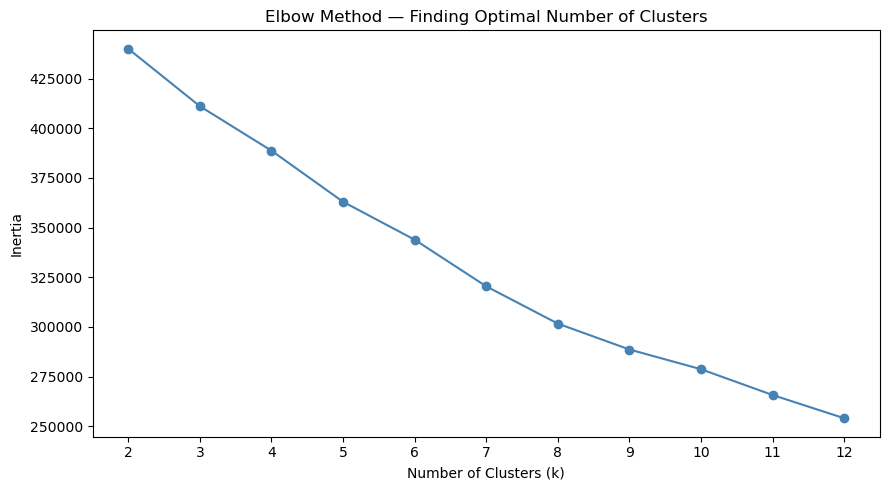

In [2]:
import os

# Test k values from 2 to 12 and record inertia (sum of squared distances to cluster centers)
# Lower inertia = tighter clusters, but adding more clusters always reduces it
inertia_values = []
k_range = range(2, 13)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f"k={k}, inertia={kmeans.inertia_:.2f}")

# Plot — the 'elbow' bend suggests the best k before adding clusters stops helping
plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia_values, marker='o', color='steelblue')
plt.title('Elbow Method — Finding Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
os.makedirs('../docs', exist_ok=True)
plt.savefig('../docs/elbow_plot.png')
plt.show()

### Method 2: Silhouette Score

The silhouette score measures how well each point fits in its own cluster vs. neighboring clusters.
A higher score means better-defined clusters.

k=2, silhouette score=0.0853
k=3, silhouette score=0.0885
k=4, silhouette score=0.1119
k=5, silhouette score=0.1238
k=6, silhouette score=0.1433
k=7, silhouette score=0.1657
k=8, silhouette score=0.1756
k=9, silhouette score=0.1791
k=10, silhouette score=0.1755
k=11, silhouette score=0.1798
k=12, silhouette score=0.1814


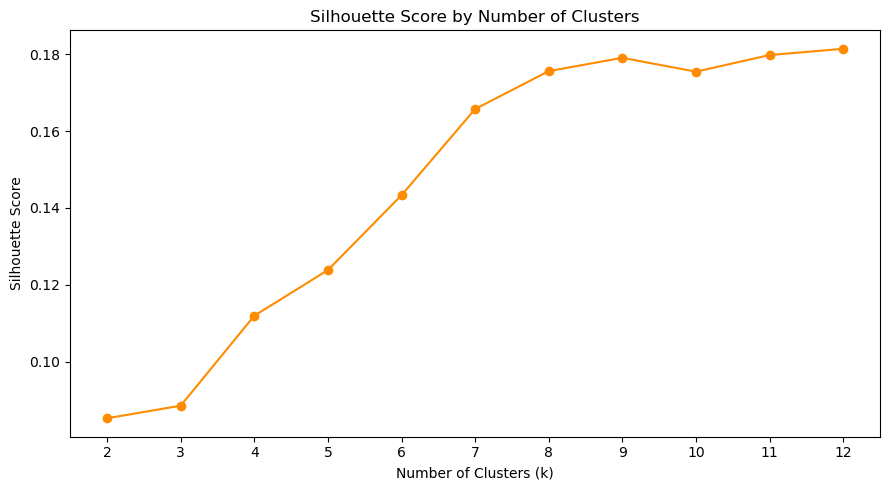

In [3]:
# Silhouette Score for each k
sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    sil_scores.append(score)
    print(f"k={k}, silhouette score={score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(9, 5))
plt.plot(k_range, sil_scores, marker='o', color='darkorange')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('../docs/silhouette_plot.png')
plt.show()

## 2. Train Final Model with Optimal k

Based on the elbow and silhouette plots above, I'll select the best k and train the final model.

In [4]:
# Pick the k with the highest silhouette score — best cluster separation
best_k = k_range[sil_scores.index(max(sil_scores))]
print(f"Best k based on silhouette score: {best_k}")

# Train the final model with the optimal k
# random_state=42 makes results reproducible
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_model.fit_predict(df_scaled)

print(f"\nCluster distribution:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} songs")

Best k based on silhouette score: 12

Cluster distribution:
  Cluster 0: 4920 songs
  Cluster 1: 3772 songs
  Cluster 2: 1798 songs
  Cluster 3: 1632 songs
  Cluster 4: 1770 songs
  Cluster 5: 4221 songs
  Cluster 6: 1067 songs
  Cluster 7: 783 songs
  Cluster 8: 4338 songs
  Cluster 9: 806 songs
  Cluster 10: 871 songs
  Cluster 11: 2119 songs


## 3. Attach Cluster Labels and Analyze

Now I'll attach the cluster labels back to the original song info and explore what each cluster looks like.

In [5]:
# Add cluster labels to the ids dataframe
df_ids['cluster'] = cluster_labels

# Also add back the original scaled features for analysis
df_result = pd.concat([df_ids, df_scaled], axis=1)

# Show sample songs from each cluster
for cluster in range(best_k):
    print(f"\n--- Cluster {cluster} Sample Songs ---")
    sample = df_result[df_result['cluster'] == cluster][['artist_name', 'track_name', 'genre']].head(5)
    print(sample.to_string(index=False))


--- Cluster 0 Sample Songs ---
        artist_name                      track_name genre
             mukesh            mohabbat bhi jhoothi   pop
stélios kazantzídis               finito la mouzika   pop
         ghantasala                 kanugona galano   pop
      mohammed rafi jahan men log sachhe ashikon ko   pop
    lata mangeshkar       maagata maagata janm gele   pop

--- Cluster 1 Sample Songs ---
  artist_name                    track_name genre
    liva weel  drømmer man om den, vågner..   pop
frankie laine                necessary evil   pop
  asha bhosle             gullyachi shapath   pop
talat mahmood ansoo to nahin hai ankhon men   pop
  a. m. rajah                 gopiparivrito   pop

--- Cluster 2 Sample Songs ---
            artist_name                               track_name genre
         the chordettes                            carolina moon   pop
        lata mangeshkar        paas nahin aaiye haath na lagaiye   pop
          andy williams it's the most wonde

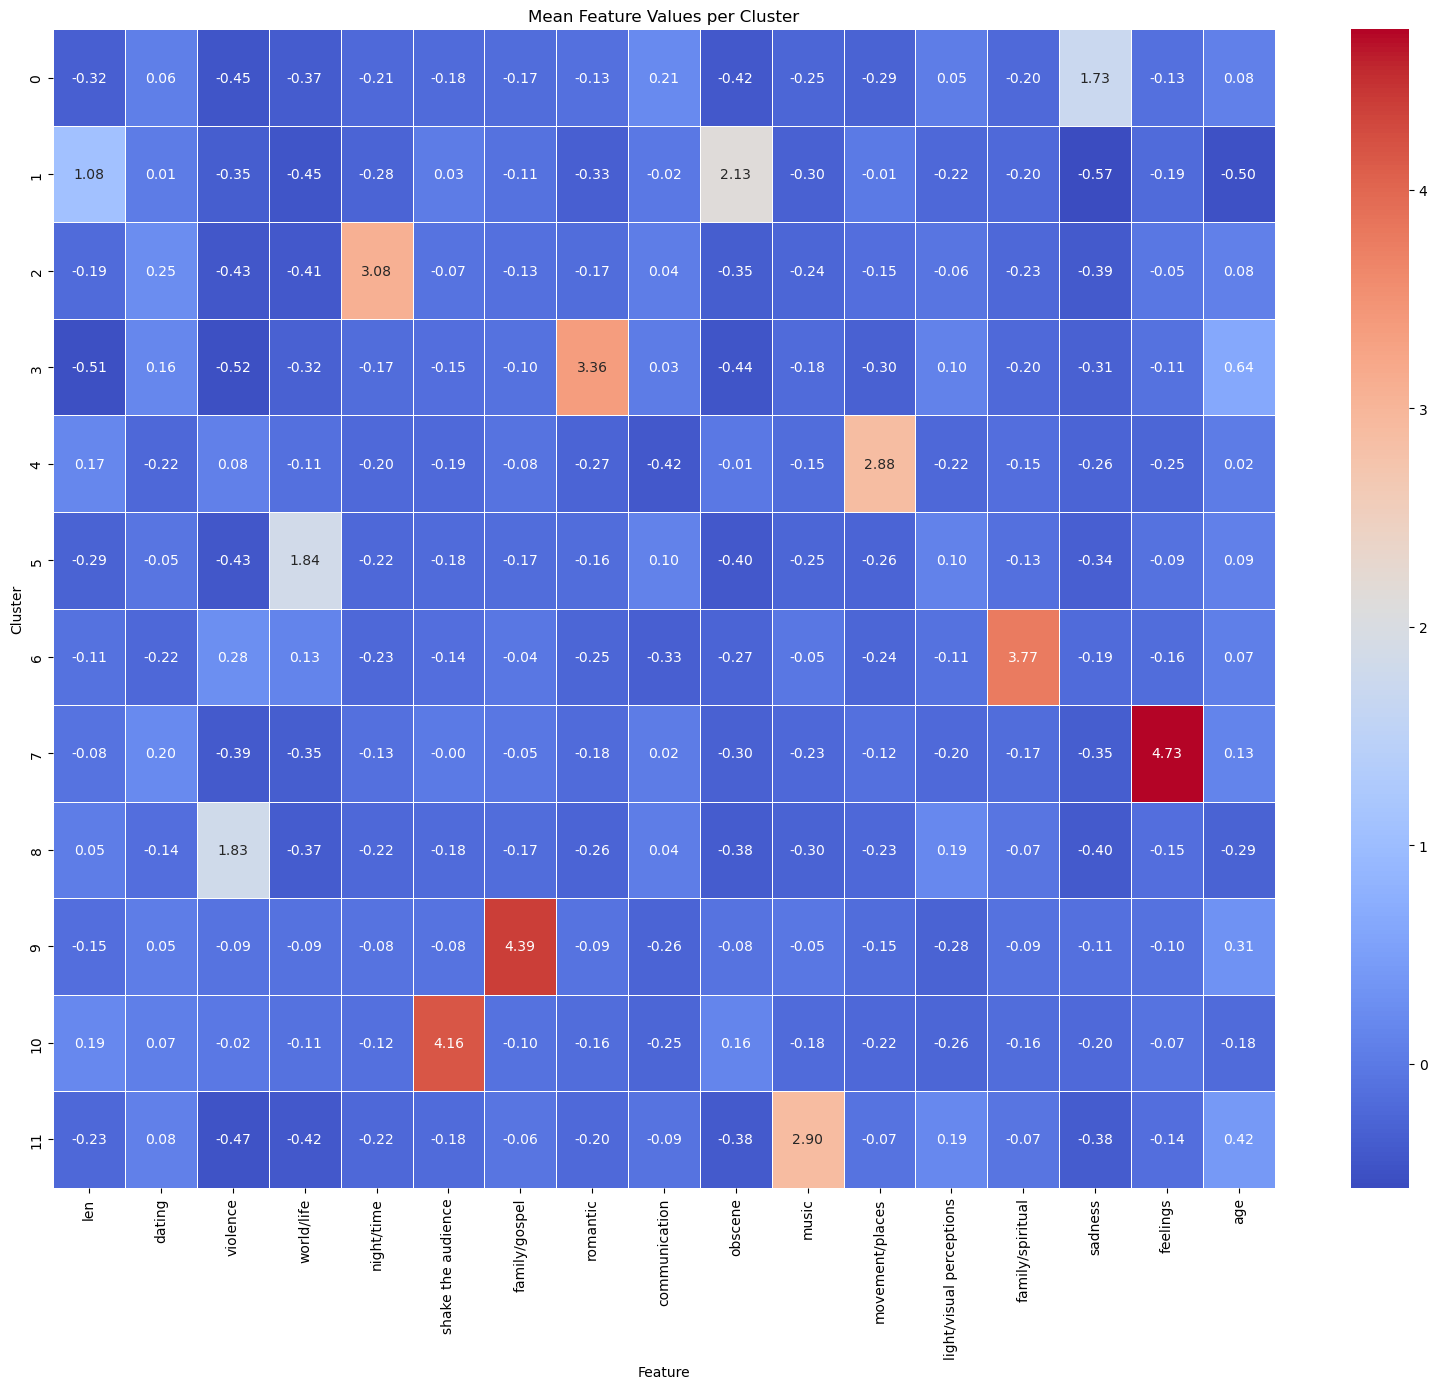

              len    dating  violence  world/life  night/time  \
cluster                                                         
0       -0.320929  0.062816 -0.452496   -0.372976   -0.206134   
1        1.076457  0.013140 -0.349078   -0.446236   -0.275124   
2       -0.192198  0.247176 -0.430185   -0.412927    3.082304   
3       -0.510541  0.157948 -0.517748   -0.318453   -0.166471   
4        0.169612 -0.223471  0.083166   -0.112301   -0.200112   
5       -0.286477 -0.052878 -0.429462    1.843931   -0.215727   
6       -0.111095 -0.222289  0.275584    0.127777   -0.226045   
7       -0.082641  0.200276 -0.394392   -0.351945   -0.130668   
8        0.054164 -0.143250  1.825553   -0.369799   -0.224312   
9       -0.152798  0.048490 -0.086606   -0.092932   -0.079075   
10       0.193338  0.067422 -0.021273   -0.109635   -0.121137   
11      -0.231526  0.076410 -0.466805   -0.420122   -0.220747   

         shake the audience  family/gospel  romantic  communication   obscene  \
cluster 

In [6]:
# Look at mean feature values per cluster to describe them
feature_cols = df_scaled.columns.tolist()
cluster_profiles = df_result.groupby('cluster')[feature_cols].mean()

# Heatmap of cluster feature profiles
plt.figure(figsize=(16, best_k + 2))
sns.heatmap(
    cluster_profiles,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Mean Feature Values per Cluster')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('../docs/cluster_profiles.png')
plt.show()

print(cluster_profiles)

## 4. Save the Clustered Training Data

In [7]:
import os
import pickle

os.makedirs('../data', exist_ok=True)

# Save training data with cluster labels — used for analysis and recommendations in notebook 4
df_result.to_csv('../data/train_with_clusters.csv', index=False)
print("Saved train_with_clusters.csv")
print("Shape:", df_result.shape)

# Pickle the trained model so notebook 4 can load and apply it to test data
with open('../data/kmeans_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Saved kmeans_model.pkl")

Saved train_with_clusters.csv
Shape: (28097, 23)
Saved kmeans_model.pkl
